# Using the number of occurrences as a feature in the matrix that i create, also while limiting the number of occurrences
with eliminating ajectives in idioms and changing instead of having the absolute number of occurrences of that lemma, instead having the percentage of that lemma out of all the adverbs (lemma count / total nb of adj)

In [16]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

In [17]:
path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

In [18]:
all_matches = corpus.search(grewpy.Request("X[upos=ADJ]").without("X[InIdiom]").without("X[Idiom]"), clustering_parameter=['X.lemma'])

In [ ]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request

# getting the total number of adj without clustering by lemma 
req1 = Request("X[upos=ADJ]").without("X[InIdiom]").without("X[Idiom]")
total_nb_adj_in_treebank = corpus.count(req1)
print(total_nb_adj_in_treebank)
print(len(all_matches))

23667
3682


In [20]:
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

In [21]:
with open("patterns_adj_no_idioms.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [22]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

In [23]:
unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [24]:
# in the last column of the matrix have the number of samples for each adverb
X = np.zeros((len(data.keys()), len(unique_features)+1))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
    X[adv2idx[adv], -1] = len(samples) / total_nb_adj_in_treebank
print(f"{X.shape=}")

X.shape=(403, 213)


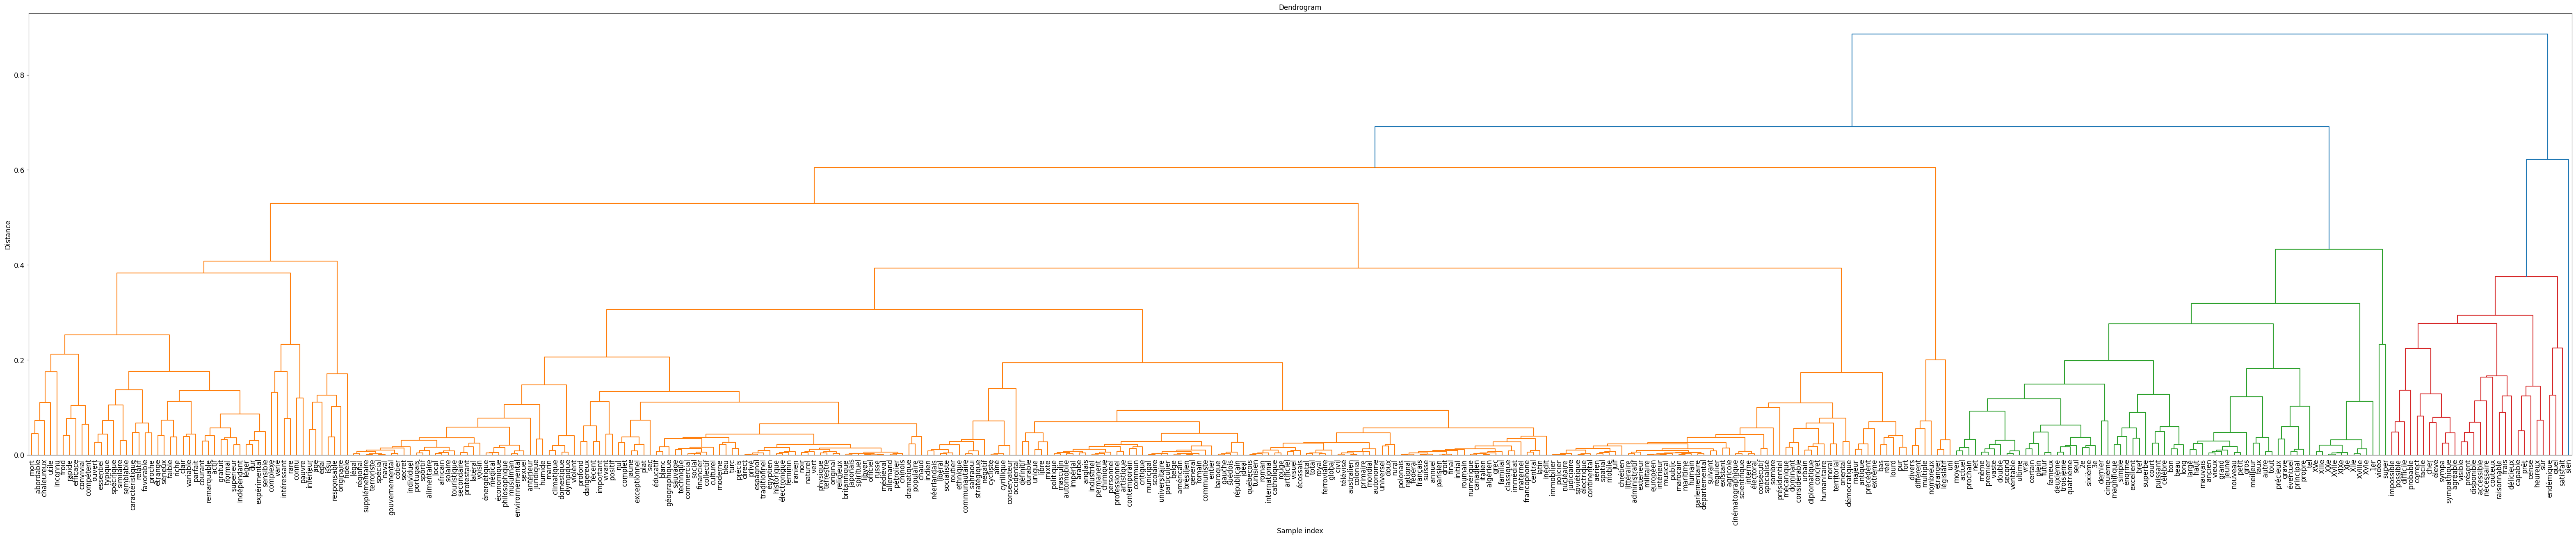

In [25]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

# Hamming or jacard for categorical data, cosine for sparse matrices (normally used in NLP)
# I compute the distance for each pair of lines, each POS
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(80, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in unique_adv],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [26]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores

# Find the optimal number of clusters
optimal_clusters, silhouette_scores = find_optimal_clusters(X, max_clusters=50)
print(f'Optimal number of clusters: {optimal_clusters}')

Number of clusters: 2, Silhouette Score: 0.6377766938214493
Number of clusters: 3, Silhouette Score: 0.48415308378869465
Number of clusters: 4, Silhouette Score: 0.4829726439446576
Number of clusters: 5, Silhouette Score: 0.45400045591935045
Number of clusters: 6, Silhouette Score: 0.4941330166337511
Number of clusters: 7, Silhouette Score: 0.4972752518492676
Number of clusters: 8, Silhouette Score: 0.48162045096279216
Number of clusters: 9, Silhouette Score: 0.22759226043635922
Number of clusters: 10, Silhouette Score: 0.23377421592133787
Number of clusters: 11, Silhouette Score: 0.23366846474196967
Number of clusters: 12, Silhouette Score: 0.24124226858932557
Number of clusters: 13, Silhouette Score: 0.2582144393431056
Number of clusters: 14, Silhouette Score: 0.25872656458179427
Number of clusters: 15, Silhouette Score: 0.2580440400525599
Number of clusters: 16, Silhouette Score: 0.23840718686668902
Number of clusters: 17, Silhouette Score: 0.23927256936474287
Number of clusters: 18

In [27]:
# see what there is in each cluster
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {unique_adv[member]}')

Cluster 1:
  accessible
  agréable
  capable
  censé
  cher
  correct
  coûteux
  difficile
  disponible
  délicieux
  endémique
  facile
  frais
  heureux
  impossible
  nécessaire
  possible
  probable
  présent
  prêt
  quel
  raisonnable
  satisfait
  sien
  sympa
  sympathique
  sûr
  visible
  élevé
Cluster 2:
  1er
  2e
  3e
  XIIIe
  XIIe
  XIXe
  XIe
  XVIIIe
  XVIIe
  XVIe
  XVe
  XXe
  abordable
  actif
  actuel
  administratif
  africain
  agricole
  algérien
  alimentaire
  allemand
  américain
  ancien
  anglais
  annuel
  antique
  antérieur
  arabe
  artificiel
  artistique
  australien
  automobile
  autonome
  autre
  aérien
  aîné
  baroque
  bas
  beau
  belge
  blanc
  bleu
  bon
  bref
  britannique
  brésilien
  canadien
  caractéristique
  catholique
  central
  certain
  chaleureux
  chaud
  chimique
  chinois
  chrétien
  cinquième
  cinématographique
  civil
  clair
  classique
  climatique
  collectif
  colonial
  commercial
  commun
  communautaire
  commun

In [15]:
# seeing as the optimal clusters is 2, if we want to have more than that, judging by silhouette scores it would make sense to choose 4
optimal_clusters = 3
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {unique_adv[member]}')

Cluster 1:
  accessible
  agréable
  capable
  censé
  cher
  correct
  coûteux
  difficile
  disponible
  délicieux
  endémique
  facile
  frais
  heureux
  impossible
  nécessaire
  possible
  probable
  présent
  prêt
  quel
  raisonnable
  satisfait
  sien
  sympa
  sympathique
  sûr
  visible
  élevé
Cluster 2:
  abordable
  actif
  administratif
  africain
  agricole
  algérien
  alimentaire
  allemand
  américain
  anglais
  annuel
  antique
  antérieur
  arabe
  artificiel
  artistique
  australien
  automobile
  autonome
  aérien
  aîné
  baroque
  bas
  belge
  blanc
  bleu
  britannique
  brésilien
  canadien
  caractéristique
  catholique
  central
  chaleureux
  chaud
  chimique
  chinois
  chrétien
  cinématographique
  civil
  clair
  classique
  climatique
  collectif
  colonial
  commercial
  commun
  communautaire
  communiste
  complet
  complexe
  compétent
  concret
  connu
  conservateur
  considérable
  consécutif
  contemporain
  continental
  convivial
  couran